# MLP baseline

En esta notebook se entrena el modelo MLP base de la Parte 1.

Se usa:

- dataset limpio, sin duplicados exactos;
- test fijo excluido;
- validación cruzada estratificada de 5 folds sobre `trainval`;
- imagen 64x64;
- optimizador Adam;
- pérdida CrossEntropyLoss;
- sin regularización adicional.

El objetivo es obtener una referencia base contra la cual comparar las modificaciones pedidas en `Preguntas.md`.

In [1]:
# ============================================================
# 1. Configuración de paths
# ============================================================
# Esta notebook está dentro de notebooks/.
# Para poder importar src/mlp_training.py, cambiamos el working
# directory al root del repo y agregamos src/ al path de Python.
# ============================================================

from pathlib import Path
import sys
import os

REPO_ROOT = Path.cwd()

if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

os.chdir(REPO_ROOT)
sys.path.append(str(REPO_ROOT / "src"))

print(f"Repo root: {REPO_ROOT}")

# ============================================================
# 2. Importar funciones de entrenamiento
# ============================================================

from mlp_training import run_cross_validation, save_experiment_outputs

Repo root: c:\Users\tomas\OneDrive\Documentos\MATERIAS ITBA\ELECTIVAS - CUATRIMESTRE X\MACHINE LEARNING y REDES NEURONALES EN BIOINGENIERÍA\skin-dataset-classification


In [2]:
# ============================================================
# 3. Configuración del MLP baseline
# ============================================================
#
# Esta configuración NO usa regularización adicional:
#
# - dropout = 0
# - batch_norm = False
# - weight_decay = 0
# - augmentation = minimal
# - initialization = default
# - early_stopping = False
#
# Sirve como punto de comparación para las modificaciones.
# ============================================================

baseline_config = {
    "experiment": "MLP_0_baseline",

    # Tamaño de entrada
    "image_size": 64,

    # Hiperparámetros de entrenamiento
    "batch_size": 32,
    "epochs": 20,
    "lr": 1e-3,

    # Regularización
    "dropout": 0.0,
    "batch_norm": False,
    "weight_decay": 0.0,
    "augmentation": "minimal",

    # Inicialización
    "initialization": "default",

    # Early stopping
    "early_stopping": False,
    "patience": 5,

    # Logging
    "tensorboard": True,
    "histogram_every": 5,

    # Reproducibilidad
    "seed": 42,
}

In [3]:
# ============================================================
# 4. Entrenamiento con 5-fold cross-validation
# ============================================================
#
# Importante:
# - Se usa solo subset == "trainval".
# - El test fijo queda completamente excluido.
# - En cada fold, un fold es validación y los otros cuatro
#   son entrenamiento.
# ============================================================

baseline_output = run_cross_validation(
    config=baseline_config,
    split_csv="data/splits/final_split_5fold.csv",
)

Experimento: MLP_0_baseline
Dispositivo: cpu
Folds usados: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Clases: ['Actinic keratosis', 'Atopic Dermatitis', 'Benign keratosis', 'Dermatofibroma', 'Melanocytic nevus', 'Melanoma', 'Squamous cell carcinoma', 'Tinea Ringworm Candidiasis', 'Vascular lesion']

Entrenando fold 0
Fold 0 terminado | val_acc=0.5625 | macro_f1=0.5377

Entrenando fold 1
Fold 1 terminado | val_acc=0.6111 | macro_f1=0.6129

Entrenando fold 2
Fold 2 terminado | val_acc=0.5734 | macro_f1=0.5752

Entrenando fold 3
Fold 3 terminado | val_acc=0.6294 | macro_f1=0.6257

Entrenando fold 4
Fold 4 terminado | val_acc=0.6224 | macro_f1=0.6313


,experiment,fold,best_epoch,image_size,batch_size,epochs,lr,dropout,batch_norm,weight_decay,augmentation,initialization,early_stopping,val_loss,val_accuracy,val_macro_f1,val_balanced_accuracy
0,MLP_0_baseline,0,12,64,32,20,0.001,0.0,False,0.0,minimal,default,False,1.417290,0.562500,0.537664,0.549911
1,MLP_0_baseline,1,17,64,32,20,0.001,0.0,False,0.0,minimal,default,False,1.575102,0.611111,0.612860,0.614124
2,MLP_0_baseline,2,18,64,32,20,0.001,0.0,False,0.0,minimal,default,False,1.346962,0.573427,0.575211,0.571429
3,MLP_0_baseline,3,16,64,32,20,0.001,0.0,False,0.0,minimal,default,False,1.197633,0.629371,0.625741,0.634855
4,MLP_0_baseline,4,20,64,32,20,0.001,0.0,False,0.0,minimal,default,False,1.495693,0.622378,0.631296,0.623657


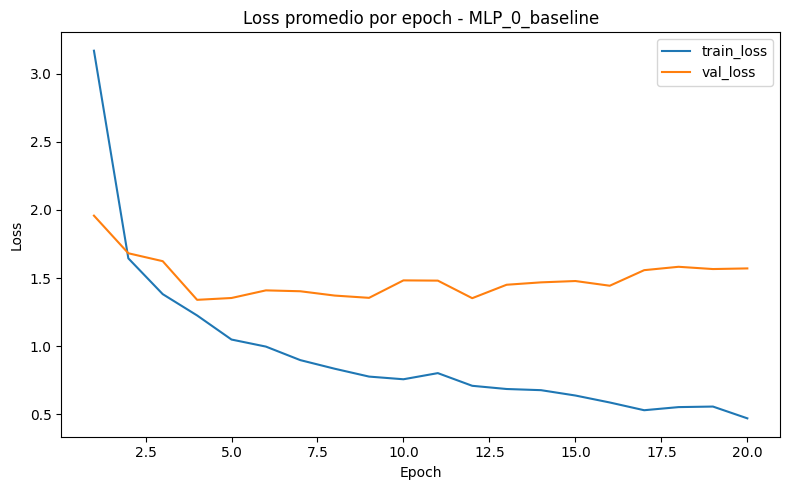

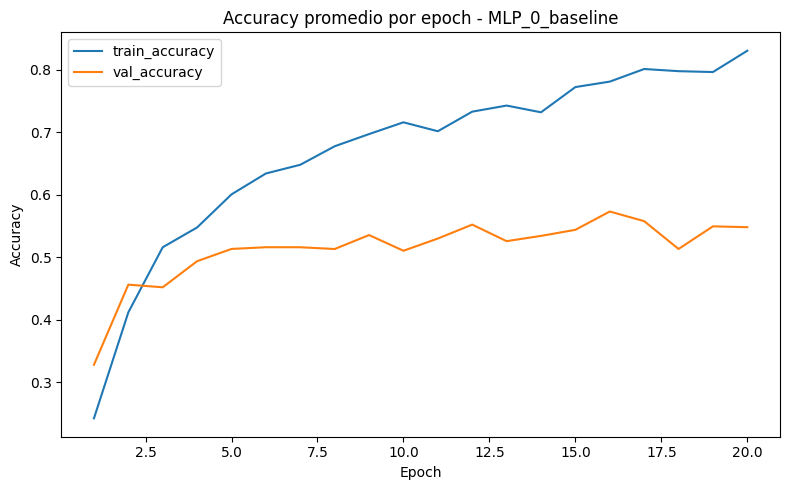

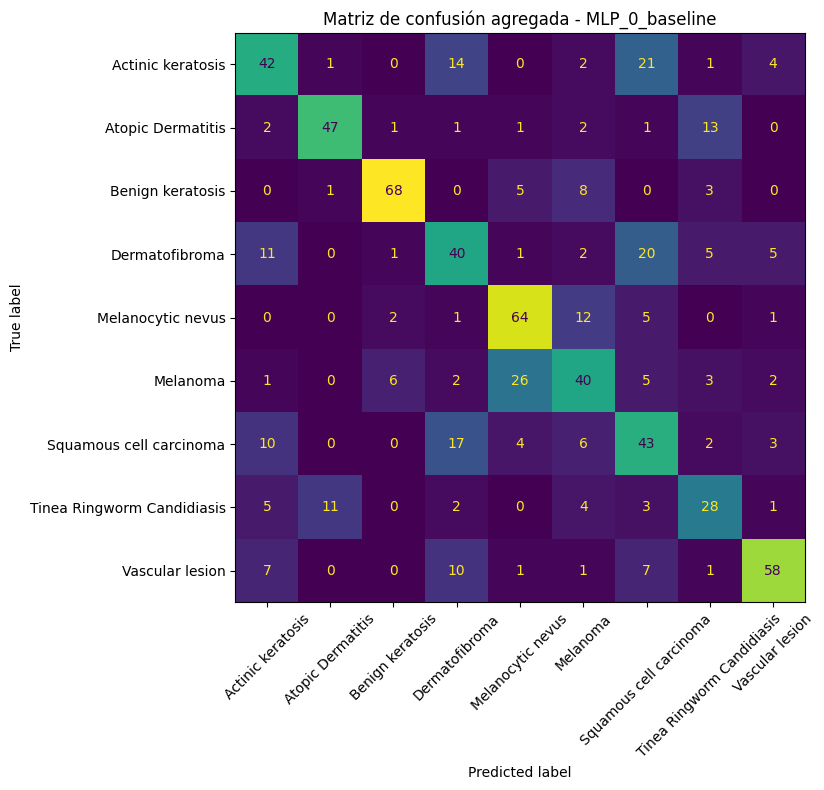

Guardado: experiments\mlp_0_baseline_fold_results.csv
Guardado: experiments\mlp_0_baseline_history.csv
Guardado: experiments\mlp_0_baseline_summary.json
Guardado: results\classification_reports\mlp_0_baseline_classification_report.txt


In [4]:
# ============================================================
# 5. Métricas por fold
# ============================================================

display(baseline_output["results_df"])

# ============================================================
# 6. Resumen promedio de validación cruzada
# ============================================================

baseline_output["summary"]

# ============================================================
# 7. Guardado de resultados
# ============================================================
#
# Se guardan:
#
# experiments/mlp_0_baseline_fold_results.csv
# experiments/mlp_0_baseline_history.csv
# experiments/mlp_0_baseline_summary.json
#
# results/training_curves/mlp_0_baseline_loss.png
# results/training_curves/mlp_0_baseline_accuracy.png
#
# results/confusion_matrices/mlp_0_baseline.png
# results/classification_reports/mlp_0_baseline_classification_report.txt
#
# También se generan logs de TensorBoard en:
# runs/mlp/MLP_0_baseline/
# ============================================================

save_experiment_outputs(
    cv_output=baseline_output,
    output_prefix="mlp_0_baseline",
)